<a href="https://colab.research.google.com/github/toothbrushered/PH16/blob/main/YOLOv8_teeth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.6 MB/s eta 0:00:00


In [ ]:
%cd /content
!git clone https://github.com/RoundFaceJ/OMNI.git
%cd /content/OMNI
!ls

/content
Cloning into 'OMNI'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 125 (delta 49), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 3.14 MiB | 9.20 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/OMNI
baseline_framework.png	data  GraphTeeth  mmdetection  README.md


In [ ]:
import os, json, yaml, shutil, zipfile
import gdown
from ultralytics.data.converter import convert_coco

# 1 — Download
if not os.path.exists('/content/OMNI.zip'):
    gdown.download(
        'https://drive.google.com/uc?id=1eSyipRJTDlAbRs0yb44l5vQjVYibRXy1&confirm=t',
        '/content/OMNI.zip', quiet=False
    )

# 2 — Extract
if not os.path.exists('/content/data/omni_coco'):
    with zipfile.ZipFile('/content/OMNI.zip', 'r') as z:
        z.extractall('/content/data/')
    print('Extracted')

# 3 — Flatten images
for split in ['train', 'val', 'test']:
    dst = f'/content/data/flat/{split}/images'
    if not os.path.exists(dst) or len(os.listdir(dst)) == 0:
        os.makedirs(dst, exist_ok=True)
        count = 0
        for root, dirs, files in os.walk(f'/content/data/omni_coco/{split}'):
            for f in files:
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    shutil.copy(os.path.join(root, f), os.path.join(dst, f))
                    count += 1
        print(f'{split} images: {count}')

# 4 — Convert labels
if not os.path.exists('/content/coco_converted'):
    convert_coco(
        labels_dir='/content/data/omni_coco/annotations/',
        use_segments=False, use_keypoints=False, cls91to80=False
    )
    print('Labels converted')

# 5 — Copy labels
for split in ['train', 'val', 'test']:
    src = f'/content/OMNI/coco_converted/labels/{split}'
    dst = f'/content/data/flat/{split}/labels'
    if not os.path.exists(dst) or len(os.listdir(dst)) == 0:
        os.makedirs(dst, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f'{split} labels: {len(os.listdir(dst))}')

# 6 — Check name match
imgs   = os.listdir('/content/data/flat/train/images')
labels = os.listdir('/content/data/flat/train/labels')
print('\nSample image names:', imgs[:3])
print('Sample label names:', labels[:3])

# 7 — Create YAML
with open('/content/data/omni_coco/annotations/instances_train.json') as f:
    coco = json.load(f)
class_names = [c['name'] for c in sorted(coco['categories'], key=lambda x: x['id'])]

with open('/content/omni.yaml', 'w') as f:
    yaml.dump({
        'path': '/content/data/flat',
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc': len(class_names),
        'names': class_names
    }, f, default_flow_style=False)

print('\nomni.yaml ready!')
print('Classes:', class_names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Downloading...
From: https://drive.google.com/uc?id=1eSyipRJTDlAbRs0yb44l5vQjVYibRXy1&confirm=t
To: /content/OMNI.zip
100%|██████████| 91.2M/91.2M [00:02<00:00, 30.7MB/s]


Extracted
train images: 2481
val images: 857
test images: 828
Annotations /content/data/omni_coco/annotations/instances_test.json: 100% ━━━━━━━━━━━━ 828/828 2.9Kit/s 0.3s
Annotations /content/data/omni_coco/annotations/instances_train.json: 100% ━━━━━━━━━━━━ 2478/2478 2.2Kit/s 1.1s
Annotations /content/data/omni_coco/annotations/instances_val.json: 100% ━━━━━━━━━━━━ 857/857 2.2Kit/s 0.4s
COCO data converted successfully.
Results saved to /content/OMNI/coco_converted
Labels converted
train labels: 2478
val labels: 857
test labels: 828

Sample image names: ['202257202208153.JPG', '201838201812211.JPG', '202336202303244.JPG']
Sample label names: ['202109202301293.txt', '201844201905174.txt', '202212202207072.txt']

omni.yaml ready!
Classes: ['HT', 'TT', 'DO', 'IOA', 'TE', 'CFOA', 'TM', 'MR', 'OB', 'FOD']


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='/content/omni.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='omni_run',
    device=0
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/omni.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=omni_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f2f25a9d60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

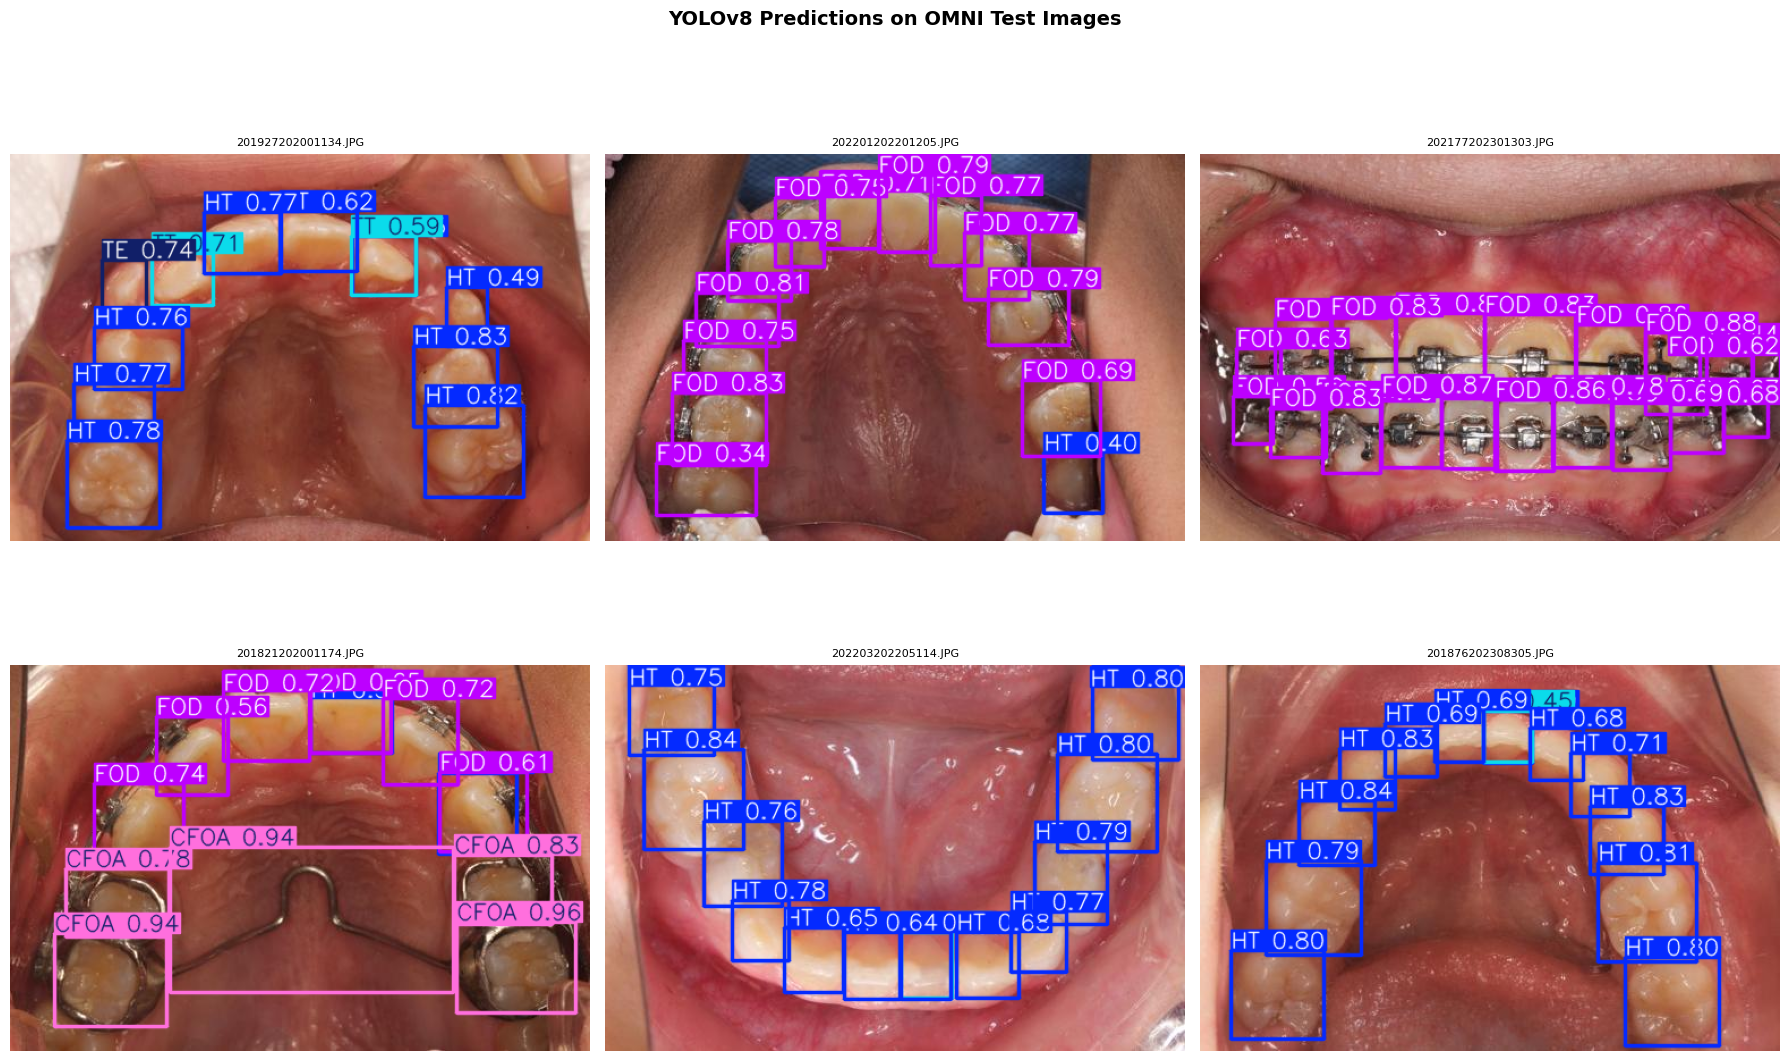

Saved to /content/predictions.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, os
from ultralytics import YOLO

# Load best model
model = YOLO('/content/OMNI/runs/detect/omni_run/weights/best.pt')

# Grab 6 random test images
test_images = glob.glob('/content/data/flat/test/images/*.JPG')[:6]

# Run prediction and display
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, img_path in zip(axes.flat, test_images):
    results = model.predict(img_path, conf=0.25, verbose=False)
    annotated = results[0].plot()  # draws boxes + labels on image
    ax.imshow(annotated[:, :, ::-1])  # BGR to RGB
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on OMNI Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/predictions.png')

HT: Healthy teeth

FOD: Fixed Orthodonic Device

CFOA: Crown/Full Coverage over Amalgam (tooth with a full crown or large restorations)

TE: Tooth Extraction(site)

In [ ]:
from google.colab import drive
import shutil
drive.mount('/content/drive')
shutil.copytree('/content/OMNI/runs/detect/omni_run',
                '/content/drive/MyDrive/omni_run', dirs_exist_ok=True)
print('Saved!')

Mounted at /content/drive
Saved!
